In [10]:
from finches.forcefields.mpipi import Mpipi_model
from finches.forcefields.calvados import calvados_model
from finches.epsilon_calculation import InteractionMatrixConstructor
import numpy as np
import matplotlib.pyplot as plt
import goose

Error importing GPy.
 If trying to run parrot-optimize, make sure to use `pip install idptools-parrot[optimize]`


/home/borna/miniconda3/envs/labconda/lib/python3.8/site-packages/alphaPredict/backend/parrot_alpha.py:128: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  brnn_network.load_st

In [2]:
def frobenius_norm(A):
    """
    Calculate the Frobenius norm of a matrix A.
    """
    fro_norm = np.sqrt(np.sum(np.square(A)))
    return A / fro_norm

def row_norm(A):
    row_norms = np.linalg.norm(A, ord=2, axis=1, keepdims=True)

    X_normalized = A / (row_norms)

    return X_normalized

In [3]:
Mpipi_GGv1_params = Mpipi_model(version = 'Mpipi_GGv1')
calvados_params = calvados_model(version = 'CALVADOS2')

In [4]:
IMC_mpipi = InteractionMatrixConstructor(parameters = Mpipi_GGv1_params)
IMC_calvados = InteractionMatrixConstructor(parameters = calvados_params)

In [22]:
# sequence = 'ADFGERTGNKRWQWQWQWP'
sequence = goose.create.sequence(length=150)

In [23]:
mpipi_interactions = IMC_mpipi.calculate_pairwise_homotypic_matrix(sequence)
calvados_interactions = IMC_calvados.calculate_pairwise_homotypic_matrix(sequence)

In [44]:
mpipi_interactions = mpipi_interactions.copy()
calvados_interactions = calvados_interactions.copy()

# Zero out the diagonals properly
np.fill_diagonal(mpipi_interactions, 0)
np.fill_diagonal(calvados_interactions, 0)

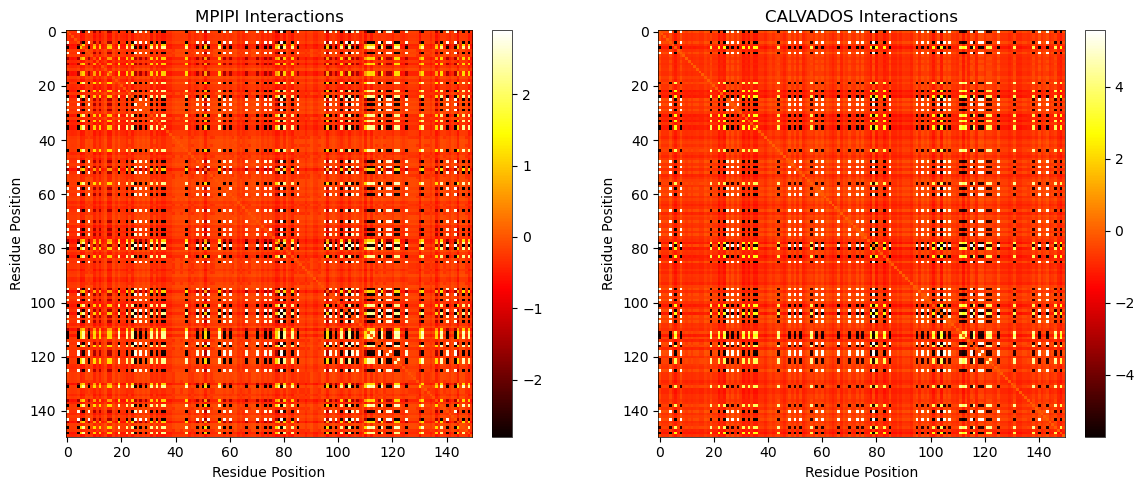

In [45]:
import matplotlib.pyplot as plt

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot MPIPI interactions
im1 = ax1.imshow(mpipi_interactions, cmap='hot', interpolation='nearest')
ax1.set_title('MPIPI Interactions')
ax1.set_xlabel('Residue Position')
ax1.set_ylabel('Residue Position')
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

# Plot CALVADOS interactions
im2 = ax2.imshow(calvados_interactions, cmap='hot', interpolation='nearest')
ax2.set_title('CALVADOS Interactions')
ax2.set_xlabel('Residue Position')
ax2.set_ylabel('Residue Position')
fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

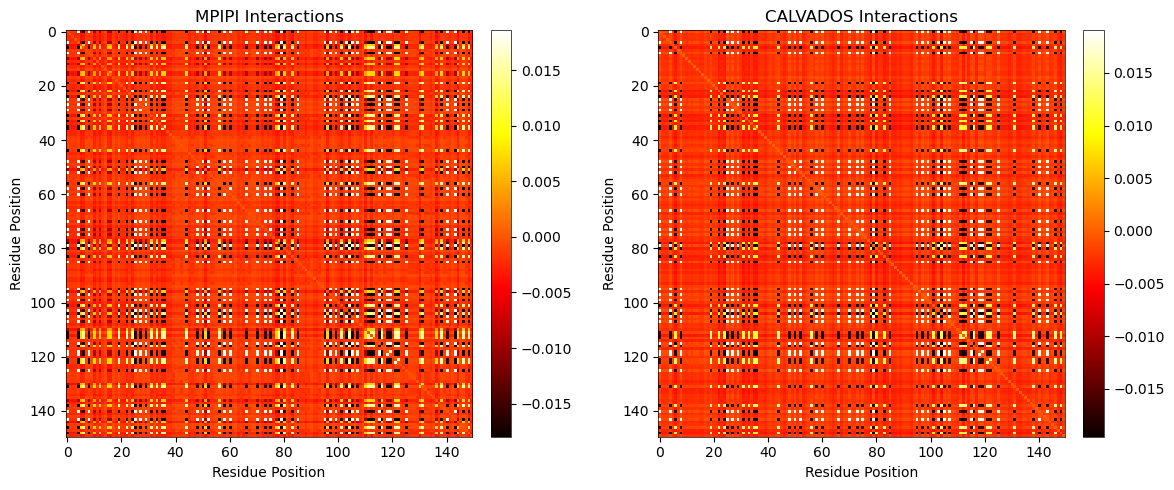

In [46]:
import matplotlib.pyplot as plt

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot MPIPI interactions
im1 = ax1.imshow(frobenius_norm(mpipi_interactions), cmap='hot', interpolation='nearest')
ax1.set_title('MPIPI Interactions')
ax1.set_xlabel('Residue Position')
ax1.set_ylabel('Residue Position')
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

# Plot CALVADOS interactions
im2 = ax2.imshow(frobenius_norm(calvados_interactions), cmap='hot', interpolation='nearest')
ax2.set_title('CALVADOS Interactions')
ax2.set_xlabel('Residue Position')
ax2.set_ylabel('Residue Position')
fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

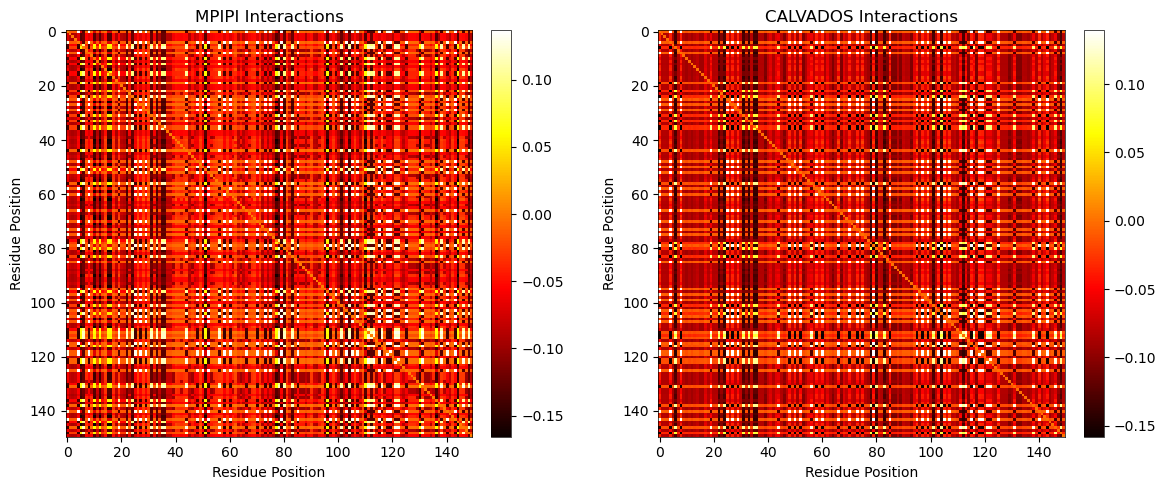

In [47]:
import matplotlib.pyplot as plt

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot MPIPI interactions
im1 = ax1.imshow(row_norm(mpipi_interactions), cmap='hot', interpolation='nearest')
ax1.set_title('MPIPI Interactions')
ax1.set_xlabel('Residue Position')
ax1.set_ylabel('Residue Position')
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

# Plot CALVADOS interactions
im2 = ax2.imshow(row_norm(calvados_interactions), cmap='hot', interpolation='nearest')
ax2.set_title('CALVADOS Interactions')
ax2.set_xlabel('Residue Position')
ax2.set_ylabel('Residue Position')
fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [21]:
fro_norm = np.linalg.norm(mpipi_interactions, ord='fro')

In [48]:
mpipi_interactions[0][:10]

array([ 0.        , -0.31307952, -0.32912168, -0.31307952,  2.77513619,
       -1.398579  , -2.6565174 , -0.17169015,  2.77513619, -0.17169015])

In [49]:
row_norm(mpipi_interactions)[0][:10]

array([ 0.        , -0.01534315, -0.01612933, -0.01534315,  0.13600163,
       -0.06854043, -0.13018846, -0.00841405,  0.13600163, -0.00841405])

In [57]:
row_norm(calvados_interactions)[0][:10]

array([ 0.        , -0.00812467, -0.00739006, -0.00812467,  0.13926994,
       -0.01454494, -0.14141989, -0.00882   ,  0.13926994, -0.00882   ])

In [56]:
sequence

'ENQNDHRSDSHNHNTHHAQKNQRGRETDTDTRGRQRRNNGTASAKQGPETDHDGSAKTDADSVNGNEGATDTQDQEQHRDRTNRGDGGQGTNQGAEHDAEQRQDREAEQTHKRKGDKGEDNKKPNESSSGHKGGNSHQKSENADHTKGRQ'

In [54]:
sequence[6]

'R'